In [ ]:
#The folder structure has been changed and the code is updated accordingly. Copy-paste the imports code block in other relevant codes if needed.

#color bar updated and y-axis is set to altitude instead of height levels in Curtains
#mass-weighted random sampling and weighted R2
#new Dataset
#update output folder if required
#Opt for m_rsg or m_sg depending on the problem at hand

output_folder_name = '23-4-2026_k-cv_paired-t-test_qg_by_(qg+qs)_locals_and_non-locals_with_HC'
Dendrogram_output_file_name = 'Dendrogram_qg_by_(qs+qg)_using_all_locals_and_non-locals.png' #write .png
HC_output_file_name = 'HC_qg_by_(qs+qg)_using_all_locals_and_non-locals.csv' #write .csv
pred_vs_actual_output_file_name1 = 'Pred_vs_Actual_qg_by_(qs+qg)_using_all_locals_and_non-locals.png' #write .png
pred_vs_actual_output_file_name2 = 'Pred_vs_Actual_qg_by_(qs+qg)_using_only_locals.png' #write .png

import time
overall_start_time = time.time()
import os
import importlib
import sys

# #Remove cached modules
# for module_name in list(sys.modules.keys()):
#     if 'dataset_init' in module_name:
#         del sys.modules[module_name]

# #Reimport
# from Tools import dataset_init

#To go up one level from 'Codes' sub-folder to 'MS' Folder, then the other sub-folders such as 'File_management' are accessible
MS_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(MS_PATH)

import numpy as np
import pandas as pd
#%matplotlib inline  #won't work for .py
import matplotlib.pyplot as plt
import xarray as xr

from File_management import json_file_editer as JFE
from Calculation import job_manager 
from Tools import dataset_init
from Log_management import Log

import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

#random forest
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

#ISLP
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
# from ISLP.models import ModelSpec as MS

from sklearn.tree import (DecisionTreeClassifier as DTC,
 DecisionTreeRegressor as DTR,
 plot_tree,
 export_text)
from sklearn.metrics import (accuracy_score,
 log_loss)
from sklearn.ensemble import \
 (RandomForestRegressor as RF,
 GradientBoostingRegressor as GBR)
from ISLP.bart import BART

import csv
#################################################################
# Log.init_log(os.path.join('./output'), filename=f"Log_ML.txt")
Log.init_log(os.path.join(MS_PATH, 'output'), filename="Log_ML.txt")
Log.add_to_log("Log nicely initialized ")

# options_json=JFE.get_json_data("options.json")
options_json = JFE.get_json_data(os.path.join(MS_PATH, "options.json"))

options_json["Header"]["status"]
chunks = {}
myJob = job_manager.JobManager(options_json)
# ds = dataset_init.ds_init_3d(myJob, chunks={}) 
ds = dataset_init.ds_init(myJob, chunks={}) 

The job folder path : /home/m/m301214/MS/output/Log_ML.txt
2026 Apr 23 17:45:45 > Log nicely initialized 
2026 Apr 23 17:45:45 > (DI0010) making data from P-O files requires small differences in the code, hardly automisable.
2026 Apr 23 17:45:45 > (DI0020) Starting PO dataset creation from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0003
2026 Apr 23 17:45:45 > (DI0021) Found 35 time-varying files in date range
2026 Apr 23 17:45:45 > (DI0022) Loading vertical grid data from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0003/pod0003_atm_vgrid_ml.nc
2026 Apr 23 17:45:46 > (DI0023) Grid variables available: ['clon_bnds', 'clat_bnds', 'height_bnds', 'height_2_bnds', 'zghalf', 'zg', 'dzghalf', 'clon', 'clat', 'height', 'height_2']
2026 Apr 23 17:45:46 > (DI0024) Dimensions in vgrid: {'ncells': 20971520, 'vertices': 3, 'height': 60, 'bnds': 2, 'height_2': 60}
2026 Apr 23 17:45:46 > (DI0037) Loading horizontal grid data from /

In [2]:
wa_renamed = ds.sel(height=slice(31.0, 90.0), height_2=slice(31.0, 90.0))['wa'].rename({'height_2': 'height'})

ds = (
    ds
    .sel(height=slice(31.0, 90.0), height_2=slice(31.0, 90.0))
    .assign(wa=wa_renamed)
)

In [3]:
#Functions

#RH from SH
def RH_from_SH(pfull, hus, ta, T_0= 273.16):
    RH = 0.26 * pfull * hus / np.exp(17.67 * (ta - T_0) / (ta - 29.65))
    return RH

#Modified R2 score
def modified_r_squared(y_test, y_test_pred, y_train):
    # Calculate the mean of the actual values
    mean_y_train = np.mean(y_train)

    # Calculate the total sum of squares
    ss_total = np.sum((y_test - mean_y_train)**2)

    # Calculate the residual sum of squares
    ss_residual = np.sum((y_test - y_test_pred)**2)

    # Calculate R^2 score
    r2_score = 1 - (ss_residual / ss_total)

    return r2_score

#Weighted R2 score 
def weighted_r_squared(y_true, y_pred, weight):
    # Calculate the mean of the actual values
    mean_y_true = np.mean(y_true)
    ss_total = np.sum( weight * (y_true - mean_y_true)**2)
    ss_residual = np.sum( weight * (y_true - y_pred)**2)
    r2_score = 1 - (ss_residual / ss_total)
    return r2_score


In [4]:
ds

<xarray.Dataset> Size: 77GB
Dimensions:    (ncells: 20971520, time: 1, height: 60, height_2: 60)
Coordinates:
    clon       (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
    clat       (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
  * time       (time) datetime64[ns] 8B 2020-01-12
  * height     (height) float64 480B 31.0 32.0 33.0 34.0 ... 87.0 88.0 89.0 90.0
  * height_2   (height_2) float64 480B 31.0 32.0 33.0 34.0 ... 88.0 89.0 90.0
Dimensions without coordinates: ncells
Data variables: (12/22)
    cell_area  (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
    pr         (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    tas        (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    clivi      (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    cllvi      (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    qgvi       (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    ...         ...
    rho        (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    dzghalf    (height, ncells) float32 5GB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    zg         (height_2, ncells) float32 5GB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    ua         (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    va         (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    pfull      (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
Attributes: (12/46)
    CDI:                      Climate Data Interface version 2.5.2.1 (https:/...
    Conventions:              CF-1.6
    number_of_grid_used:      55
    grid_file_uri:            http://icon-downloads.mpimet.mpg.de/grids/publi...
    uuidOfHGrid:              9a8d03ba-2027-11ef-a2ba-c74e1b4d7fe9
    institution:              Max Planck Institute for Meteorology/Deutscher ...
    ...                       ...
    topography:               modified SRTM30
    symmetry:                 along equator
    subcentre:                0
    ICON_grid_file_uri:       http://icon-downloads.mpimet.mpg.de/grids/publi...
    optimization:             spring dynamics
    NCO:                      netCDF Operators version 5.0.6 (Homepage = http...

In [5]:
#Values for hus, pfull and ta above the current cell
height_range = range(31, 91, 1)

#Create a list to store datasets for each height level
ds_list = []

for ht in height_range:
    #Select where BOTH height and height_2 equal the same value
    ds_ht = ds.sel(height=ht, height_2=ht)
    ds_list.append(ds_ht)

#Concatenate along the height dimension
ds_subset = xr.concat(ds_list, dim='height')

#EXTRACT hus VALUES FROM ABOVE
hus_above = ds_subset['hus'].shift(height=1)
#Handle boundary conditions
hus_above = hus_above.fillna(ds_subset['hus']) 
#Add to dataset
ds_subset['hus_above'] = hus_above

#EXTRACT zg VALUES FROM ABOVE
zg_above = ds_subset["zg"].shift(height=1)
zg_above = zg_above.fillna(ds_subset["zg"])
ds_subset["zg_above"] = zg_above

#del_hus/del_z
ds_subset['del_hus/del_z']= ( ( ds_subset['hus_above'] - ds_subset['hus'] ) / ( ds_subset['zg_above'] - ds_subset['zg'] ) )

ds_subset['del_hus/del_z'] = ds_subset['del_hus/del_z'].where(
    ds_subset['zg_above'] != ds_subset['zg'],
    ds_subset['del_hus/del_z'].shift(height=-1)
)

#EXTRACT ta VALUES FROM ABOVE
ta_above = ds_subset['ta'].shift(height=1)
ta_above = ta_above.fillna(ds_subset['ta'])
ds_subset['ta_above'] = ta_above

#del_ta/del_z
ds_subset['del_ta/del_z']= ( ( ds_subset['ta_above'] - ds_subset['ta'] ) / ( ds_subset['zg_above'] - ds_subset['zg'] ) )

ds_subset['del_ta/del_z'] = ds_subset['del_ta/del_z'].where(
    ds_subset['zg_above'] != ds_subset['zg'],
    ds_subset['del_ta/del_z'].shift(height=-1)
)

#EXTRACT wa VALUES FROM ABOVE
wa_above = ds_subset['wa'].shift(height=1)
wa_above = wa_above.fillna(ds_subset['wa'])
ds_subset['wa_above'] = wa_above

#del_wa/del_z
ds_subset['del_wa/del_z']= ( ( ds_subset['wa_above'] - ds_subset['wa'] ) / ( ds_subset['zg_above'] - ds_subset['zg'] ) )

ds_subset['del_wa/del_z'] = ds_subset['del_wa/del_z'].where(
    ds_subset['zg_above'] != ds_subset['zg'],
    ds_subset['del_wa/del_z'].shift(height=-1)
)

#EXTRACT pfull VALUES FROM ABOVE
pfull_above = ds_subset['pfull'].shift(height=1)
pfull_above = pfull_above.fillna(ds_subset['pfull'])
ds_subset['pfull_above'] = pfull_above

#del_pfull/del_z
ds_subset['del_pfull/del_z']= ( ( ds_subset['pfull_above'] - ds_subset['pfull'] ) / ( ds_subset['zg_above'] - ds_subset['zg'] ) )

ds_subset['del_pfull/del_z'] = ds_subset['del_pfull/del_z'].where(
    ds_subset['zg_above'] != ds_subset['zg'],
    ds_subset['del_pfull/del_z'].shift(height=-1)
)

#EXTRACT RH VALUES FROM ABOVE
ds_subset['RH']=RH_from_SH(ds_subset['pfull'], ds_subset['hus'], ds_subset['ta'])
ds_subset['RH_above']=RH_from_SH(ds_subset['pfull_above'], ds_subset['hus_above'], ds_subset['ta_above'])
ds_subset["RH_above"] = ds_subset["RH_above"].fillna(ds_subset["RH"]) #remove this step?

#del_RH/del_z
# ds_subset['del_RH/del_z']= 0.5 * ( ( ( ds_subset['RH_above'] - ds_subset['RH'] ) / ( ds_subset['dzghalf_above'] - ds_subset['dzghalf'] ) ) + ( ( ds_subset['RH'] - ds_subset['RH_below'] ) / ( ds_subset['dzghalf'] - ds_subset['dzghalf_below'] ) )  )

#del_RH/del_z
ds_subset['del_RH/del_z']= ( ( ds_subset['RH_above'] - ds_subset['RH'] ) / ( ds_subset['zg_above'] - ds_subset['zg'] ) )

ds_subset['del_RH/del_z'] = ds_subset['del_RH/del_z'].where(
    ds_subset['zg_above'] != ds_subset['zg'],
    ds_subset['del_RH/del_z'].shift(height=-1)
)

#Check
# if (
#     (ds_subset.sel(height=89)["zg_above"] == ds_subset.sel(height=88)["zg"]).all()
# ):
#     print("All assertions passed for zg!")
# else:
#     print("Assertion failed for zg!")

#EXTRACT clw+cli VALUES FROM ABOVE
ds_subset['clw+cli'] = ds_subset['clw'] + ds_subset['cli']
clw_cli_above = ds_subset['clw+cli'].shift(height=1)
clw_cli_above = clw_cli_above.fillna(ds_subset['clw+cli'])
ds_subset['clw+cli_above'] = clw_cli_above

#del_clw+cli/del_z
ds_subset['del_clw+cli/del_z']= ( ( ds_subset['clw+cli_above'] - ds_subset['clw+cli'] ) / ( ds_subset['zg_above'] - ds_subset['zg'] ) )

ds_subset['del_clw+cli/del_z'] = ds_subset['del_clw+cli/del_z'].where(
    ds_subset['zg_above'] != ds_subset['zg'],
    ds_subset['del_clw+cli/del_z'].shift(height=-1)
)

#EXTRACT qr+qg+qs VALUES FROM ABOVE
ds_subset['qr+qg+qs']=ds_subset['qr']+ds_subset['qg']+ds_subset['qs']
qr_qg_qs_above = ds_subset['qr+qg+qs'].shift(height=1)
qr_qg_qs_above = qr_qg_qs_above.fillna(ds_subset['qr+qg+qs'])
ds_subset['qr+qg+qs_above']=qr_qg_qs_above

#del_qr+qg+qs/del_z
ds_subset['del_qr+qg+qs/del_z']= ( ( ds_subset['qr+qg+qs_above'] - ds_subset['qr+qg+qs'] ) / ( ds_subset['zg_above'] - ds_subset['zg'] ) )

ds_subset['del_qr+qg+qs/del_z'] = ds_subset['del_qr+qg+qs/del_z'].where(
    ds_subset['zg_above'] != ds_subset['zg'],
    ds_subset['del_qr+qg+qs/del_z'].shift(height=-1)
)


In [6]:
#Calculate condensate and precipitate fractions
total = ds_subset['clw'] + ds_subset['cli']
ds_subset['clw/(clw+cli)'] = ds_subset['clw'].where(total != 0, 0) / total.where(total != 0, 1)
ds_subset['cli/(clw+cli)'] = ds_subset['cli'].where(total != 0, 0) / total.where(total != 0, 1)

total_precipitates = ds_subset['qr'] + ds_subset['qs'] + ds_subset['qg']
ds_subset['qr/(qr+qs+qg)'] = ds_subset['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
ds_subset['qs/(qr+qs+qg)'] = ds_subset['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
ds_subset['qg/(qr+qs+qg)'] = ds_subset['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

#CONVERT TO DATAFRAME

# First, filter ds_subset to only include the desired height levels
# height_range_filtered = range(31, 91, 5)  # 31, 36, 41, 46, 51, 56, 61, 66, 71, 76, 81, 86
height_range_filtered = range(31, 91, 5)  

# Select only these height levels from ds_subset
ds_subset_filtered = ds_subset.sel(height=list(height_range_filtered))

# # Now convert to dataframe
# df = ds_subset_filtered.to_dataframe().reset_index() #This line could probably lead to the kernel crash

In [7]:
#Alternative-1
# Process one height level at a time
df_list = []

for ht in height_range_filtered:
    print(f"Processing height level {ht}...")
    
    # Select single height level
    ds_single = ds_subset_filtered.sel(height=ht)
    
    # Convert just this height level to dataframe
    df_single = ds_single.to_dataframe().reset_index()
    
    df_list.append(df_single)
    
    # Optional: clear memory
    del ds_single

# Concatenate all height levels
df = pd.concat(df_list, ignore_index=True)
del df_list  # Free memory

print(f"Final dataframe shape: {df.shape}")
print(f"Expected rows (if no missing data): {len(height_range_filtered) * ds['ncells'].size}") #check

# Verify height == height_2 for all rows
print(f"\nRows where height != height_2: {(df['height'] != df['height_2']).sum()}")

# Verify we only have the desired height levels
print(f"\nUnique height values in df: {sorted(df['height'].unique())}")

print("\nSample of hus values:")
print(df[['height', 'height_2', 'clat', 'clon', 'hus', 'hus_above']].head(15))

# Check for duplicates
duplicates = df.duplicated(subset=['clat', 'clon', 'height']).sum()
print(f"\nNumber of duplicate (clat, clon, height) combinations: {duplicates}")

# Check for NaN values in hus (not hus_above/below)
print(f"\nNaN count in original hus: {df['hus'].isna().sum()}")
print(f"NaN count in hus_above: {df['hus_above'].isna().sum()}")

Processing height level 31...


Processing height level 36...
Processing height level 41...
Processing height level 46...
Processing height level 51...
Processing height level 56...
Processing height level 61...
Processing height level 66...
Processing height level 71...
Processing height level 76...
Processing height level 81...
Processing height level 86...
Final dataframe shape: (251658240, 51)
Expected rows (if no missing data): 251658240

Rows where height != height_2: 0

Unique height values in df: [np.float64(31.0), np.float64(36.0), np.float64(41.0), np.float64(46.0), np.float64(51.0), np.float64(56.0), np.float64(61.0), np.float64(66.0), np.float64(71.0), np.float64(76.0), np.float64(81.0), np.float64(86.0)]

Sample of hus values:
    height  height_2      clat      clon       hus  hus_above
0     31.0      31.0  0.918163  1.274090  0.000003   0.000003
1     31.0      31.0  0.918508  1.275076  0.000003   0.000003
2     31.0      31.0  0.918508  1.273105  0.000003   0.000003
3     31.0      31.0  0.917471  1.

In [8]:
old_df_len = len(df)
print("Length of the old df: ", old_df_len)
threshold = 5e-12
df_new = df[(df['cli'] + df['clw'] + df['qr'] + df['qg'] + df['qs']) >= threshold]
# print('df- After threshold-1:')
# print(df_new)
if df_new.empty:
    df_new = df

df = df_new
new_df_len = len(df)
# print('df after threshold-2:\n', df)
print("Length of the new df: ", new_df_len)
percent_data_removed=100*(old_df_len - new_df_len)/old_df_len
print("Percentage of data removed after setting the threshold: ", percent_data_removed, "%") #work on this
print("Percentage of cells having sum of condensates and preicipitates greater than the threshold: ", (100-percent_data_removed),"%")

Length of the old df:  251658240


Length of the new df:  63411886
Percentage of data removed after setting the threshold:  74.80238040288289 %
Percentage of cells having sum of condensates and preicipitates greater than the threshold:  25.19761959711711 %


In [9]:
count=0
for i in df['RH']:
    if i>100 or i<0:
        count+=1
print("Out_of_range count = ", count)
print("Out_of_range count percent = ", 100*count/len(df['RH']))

df['RH']= df['RH'].clip(lower=0, upper=100)

count=0
for i in df['RH_above']:
    if i>100 or i<0:
        count+=1
print("Out_of_range count = ", count)
print("Out_of_range count percent = ", 100*count/len(df['RH_above']))

df['RH_above']= df['RH_above'].clip(lower=0, upper=100)

Out_of_range count =  571480
Out_of_range count percent =  0.9012190553676325
Out_of_range count =  514910
Out_of_range count percent =  0.8120086508702801


In [10]:
col=df.pop('RH')
df.insert(16, 'RH', col) #hus is at 16th position

col=df.pop('RH_above')
df.insert(17, 'RH_above', col) 

df['clw+cli']=df['clw']+df['cli']
col=df.pop('clw+cli')
df.insert(35, 'clw+cli', col) 

#Include 'cloud liquid water path + cloud ice path' as a feature.
df['cllvi+clivi']=df['cllvi']+df['clivi']
col=df.pop('cllvi+clivi')
df.insert(36, 'cllvi+clivi', col) 

df.index = range(len(df))

In [11]:
df['m_gs']=df['dzghalf']*df['rho']*df['cell_area']* (df['qg']+df['qs'])

col=df.pop('m_gs')
df.insert(37, 'm_gs', col) 

df = df.sort_values(by='m_gs', ascending=False)
df = df.reset_index(drop=True)
total_mass = df['m_gs'].sum()
df['cum_mass'] = df['m_gs'].cumsum()

col=df.pop('cum_mass')
df.insert(38, 'cum_mass', col) 

In [12]:
#Adding another column; qr+qg+qs and use it later as an input feature
df['qr+qg+qs'] = df['qr'] + df['qg'] + df['qs']

col=df.pop('qr+qg+qs')
df.insert(39, 'qr+qg+qs', col)

#Adding another column; qr+qs+qg and use it later as an input feature
df['(qg+qs)/(qr+qs+qg)'] = (df['qg'] + df['qs']) / (df['qr'] + df['qg'] + df['qs'])

col=df.pop('del_hus/del_z')
df.insert(40, 'del_hus/del_z', col) 

col=df.pop('del_ta/del_z')
df.insert(41, 'del_ta/del_z', col) 

col=df.pop('del_pfull/del_z')
df.insert(42, 'del_pfull/del_z', col) 

col=df.pop('del_clw+cli/del_z')
df.insert(43, 'del_clw+cli/del_z', col)  

col=df.pop('del_qr+qg+qs/del_z')
df.insert(44, 'del_qr+qg+qs/del_z', col)  

col=df.pop('del_wa/del_z')
df.insert(45, 'del_wa/del_z', col)  

col=df.pop('(qg+qs)/(qr+qs+qg)')
df.insert(46, '(qg+qs)/(qr+qs+qg)', col)

#Adding another column; qr+qs+qg and use it later as an input feature
df['qg/(qs+qg)'] = df['qg'] / (df['qg'] + df['qs'])

col=df.pop('qg/(qs+qg)')
df.insert(55, 'qg/(qs+qg)', col)

In [13]:
#Mass-weighted Random Sampling
n_samples= int(np.floor(len(df) * 0.1)) #we are taking a way smaller dataset because of this 
# n_samples= int(np.floor(len(df))) 
np.random.seed(29)
random_values = np.random.uniform(0, total_mass, size=n_samples)
print('Random values: ', random_values)
indices= np.searchsorted(df['cum_mass'].values, random_values)
df_orig=df
df = df.iloc[indices].reset_index(drop=True)

Random values:  [3.49410680e+12 1.15250983e+12 2.96338853e+11 ... 4.01666632e+12
 3.19401965e+12 2.35882842e+12]


In [14]:
# final_df_length=df.length
final_df_length=len(df)
print("The final length of the dataframe is ", final_df_length)

diff = (old_df_len - final_df_length)
percent_diff=(diff*100/old_df_len)
print("Percent difference in the lengths of old df and final df is: ", percent_diff, "%")
print("Percentage of cells having sum of condensates and preicipitates greater than the threshold: ", (100-percent_diff), "%")

The final length of the dataframe is  6341188
Percent difference in the lengths of old df and final df is:  97.48023827870686 %
Percentage of cells having sum of condensates and preicipitates greater than the threshold:  2.5197617212931362 %


In [15]:
#OBtain lon and lat from clon and clat respectively
df['lon'] = df['clon']*180/np.pi #in degrees
df['lat'] = df['clat']*180/np.pi #in degrees
df.columns

Index(['ncells', 'time', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'hus', 'RH', 'RH_above',
       'ta', 'wa', 'rho', 'dzghalf', 'zg', 'ua', 'va', 'pfull', 'clon', 'clat',
       'height', 'height_2', 'hus_above', 'zg_above', 'ta_above', 'clw+cli',
       'cllvi+clivi', 'm_gs', 'cum_mass', 'qr+qg+qs', 'wa_above',
       'del_hus/del_z', 'del_ta/del_z', 'del_pfull/del_z', 'del_clw+cli/del_z',
       'del_qr+qg+qs/del_z', 'pfull_above', 'del_wa/del_z',
       '(qg+qs)/(qr+qs+qg)', 'del_RH/del_z', 'clw+cli_above', 'qr+qg+qs_above',
       'clw/(clw+cli)', 'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)',
       'qg/(qr+qs+qg)', 'qg/(qs+qg)', 'lon', 'lat'],
      dtype='str')

In [16]:
final_df_length=len(df)
print("Length of the dataframe is: ", final_df_length)

len_df_without_non_locals = 6341188 #noted from the code where only local features were used

diff_in_df_lengths = len_df_without_non_locals - final_df_length
percent_diff_in_df_lengths = (diff_in_df_lengths * 100) / len_df_without_non_locals
print("Difference in lengths of dataframes with and without non-local features: ", diff_in_df_lengths)
print("Percentage difference in lengths of dataframes with and without non-local features: ", percent_diff_in_df_lengths, "%")

Length of the dataframe is:  6341188
Difference in lengths of dataframes with and without non-local features:  0
Percentage difference in lengths of dataframes with and without non-local features:  0.0 %


Hierarchical Clustering

Shape of transposed DataFrame: (21, 6341188)
Shape of linkage matrix: (20, 4)
First 10 rows of linkage DataFrame:
    c1  c2  distance  size
0   8   9  0.003755     2
1   2   4  0.154151     2
2   3  22  0.295883     3
3   5  11  0.354713     2
4   0   7  0.495686     2
5  17  18  0.495785     2
6  14  21  0.546087     3
7  10  12  0.571809     2
8  13  19  0.612453     2
9  20  28  0.638801     3


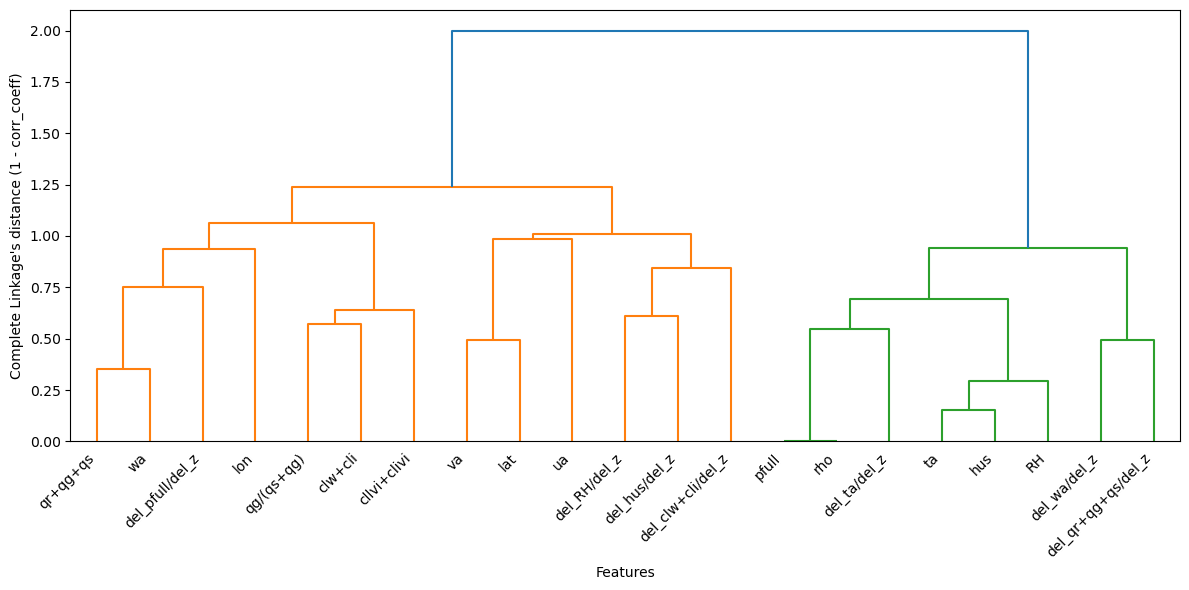

In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler

# df_orig=df.copy()
#Select ft's
feature_names= ['lat','lon','hus' ,'RH','ta','wa','ua','va','rho','pfull','clw+cli','qr+qg+qs','qg/(qs+qg)','del_hus/del_z', 'del_ta/del_z', 'del_pfull/del_z', 'del_clw+cli/del_z',
       'del_qr+qg+qs/del_z','del_wa/del_z','del_RH/del_z','cllvi+clivi'] # [lat, lon, RH,ta,wa,ua,va,pfull,clw+cli,qr+qg+qs]
# feature_names= ['lat','lon','hus' ,'RH','ta','wa','ua','va','rho','pfull','clw+cli','qr+qg+qs'] # [lat, lon, RH,ta,wa,ua,va,pfull,clw+cli,qr+qg+qs]
# feature_names= ['lat','lon','hus' ,'RH','ta','wa','ua','va','rho','pfull','clw+cli','qr+qg+qs'] # [lat, lon, RH,ta,wa,ua,va,pfull,clw+cli,qr+qg+qs]
df_features = df[feature_names]

#Standardize ft's
scaler= StandardScaler()
df_scaled= scaler.fit_transform(df_features)
df_scaled= pd.DataFrame(df_scaled, columns=df_features.columns)

#Transpose so ft's are in rows
df_transposed = df_scaled.transpose()
print("Shape of transposed DataFrame:", np.shape(df_transposed))

# linked=linkage(df_transposed, method='complete', metric='euclidean')
linked=linkage(df_transposed, method='complete', metric='correlation')
print("Shape of linkage matrix:", np.shape(linked))

df_linked= pd.DataFrame(linked, columns=['c1','c2','distance','size'])
df_linked[['c1','c2','size']]= df_linked[['c1','c2','size']].astype('int')
print("First 10 rows of linkage DataFrame:\n", df_linked.head(10))

#Create the Dendrogram
plt.figure(figsize=(12,6))
dendrogram(linked,
            orientation='top',
              labels=df_transposed.index,
                distance_sort='descending',
                  show_leaf_counts=True)

plt.xlabel('Features')
# plt.ylabel('Complete Linkage\'s distance (Euclidean)')
plt.ylabel('Complete Linkage\'s distance (1 - corr_coeff)')

plt.xticks(rotation=45, ha='right')   #tilt labels
plt.tight_layout()                    #adjust spacing automatically

Dendrogram_output_path = os.path.join('../output', output_folder_name, Dendrogram_output_file_name)
plt.savefig(Dendrogram_output_path,  bbox_inches='tight') #bbox_inches='tight' so that labels don't get cut off

plt.show()

In [18]:
#Now, let's set a limit on the number of clusters
num_clusters=3

labels= fcluster(linked, t=num_clusters, criterion='maxclust')
print("Cluster labels for each feature:", labels)

correlations=[]
for col in df_features.columns:
    corr=df['qg/(qs+qg)'].corr(df[col])
    corr=round(corr,3)
    correlations.append(corr)

df_clusters= pd.DataFrame(list(zip(df_features.columns, labels, correlations)),
                          columns=['feature', 'cluster', 'corr'])

df_clusters['abs_corr']= df_clusters['corr'].abs()

df_clusters.sort_values(by=['cluster','abs_corr'], ascending=[True, False], inplace=True) #inplace=True changes this very df itself
df_clusters.reset_index(drop=True, inplace=True) #drop=True prevents the old indices from being added as a column
print("DataFrame of clustered features:\n", df_clusters)

HC_output_path = os.path.join('../output', output_folder_name, HC_output_file_name)
df_clusters.to_csv(HC_output_path, index=False)


Cluster labels for each feature: [2 3 1 1 1 3 2 2 1 1 3 3 3 2 1 3 2 1 1 2 3]


DataFrame of clustered features:
                feature  cluster   corr  abs_corr
0                  hus        1  0.353     0.353
1                   RH        1  0.300     0.300
2                   ta        1  0.248     0.248
3                pfull        1  0.093     0.093
4         del_wa/del_z        1  0.080     0.080
5                  rho        1  0.064     0.064
6         del_ta/del_z        1  0.047     0.047
7   del_qr+qg+qs/del_z        1  0.023     0.023
8        del_hus/del_z        2 -0.238     0.238
9                   ua        2 -0.186     0.186
10                 lat        2 -0.064     0.064
11   del_clw+cli/del_z        2  0.042     0.042
12                  va        2 -0.030     0.030
13        del_RH/del_z        2  0.017     0.017
14          qg/(qs+qg)        3  1.000     1.000
15             clw+cli        3  0.428     0.428
16         cllvi+clivi        3  0.361     0.361
17            qr+qg+qs        3  0.248     0.248
18                  wa        3  0.

Number of features in cluster 1: 8
Number of features in cluster 2: 6
Number of features in cluster 3: 7


Text(0.5, 1.0, 'Cluster 2 and 3')

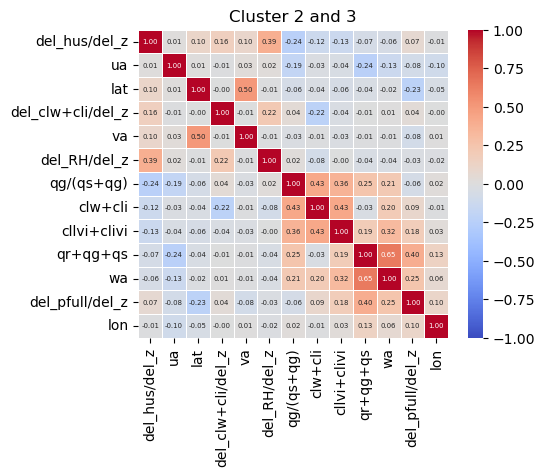

In [19]:
c1_features= df_clusters[df_clusters['cluster']==1]['feature'].tolist()
c2_features= df_clusters[df_clusters['cluster']==2]['feature'].tolist()
c3_features= df_clusters[df_clusters['cluster']==3]['feature'].tolist()

print("Number of features in cluster 1:", len(c1_features))
print("Number of features in cluster 2:", len(c2_features))
print("Number of features in cluster 3:", len(c3_features))

#Plot correlns of ft's in clusters 2 and 3
corr = df_features[np.append(c2_features, c3_features)].corr()

#plot correln. matrix
plt.figure(figsize=(5,4))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5,
            fmt=".2f",
            annot_kws={"size":5},
            vmin=-1, vmax=1)

plt.title('Cluster 2 and 3')

Text(0.5, 1.0, 'Cluster 1 and 2')

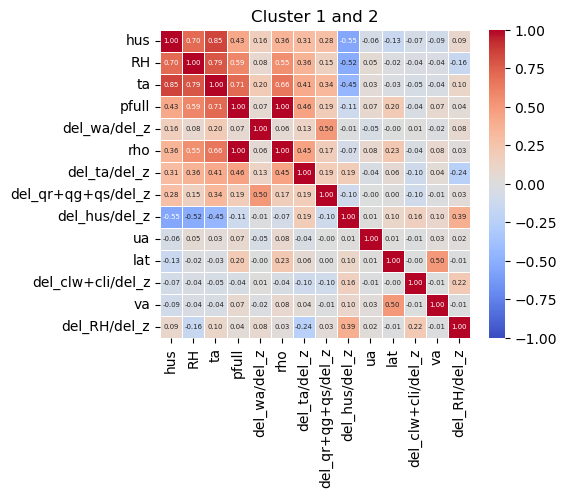

In [20]:
#Plot correlns of ft's in clusters 1 and 2
corr = df_features[np.append(c1_features, c2_features)].corr()

#plot correln. matrix
plt.figure(figsize=(5,4))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5,
            fmt=".2f",
            annot_kws={"size":5},
            vmin=-1, vmax=1)

plt.title('Cluster 1 and 2')

Text(0.5, 1.0, 'Cluster 1 and 3')

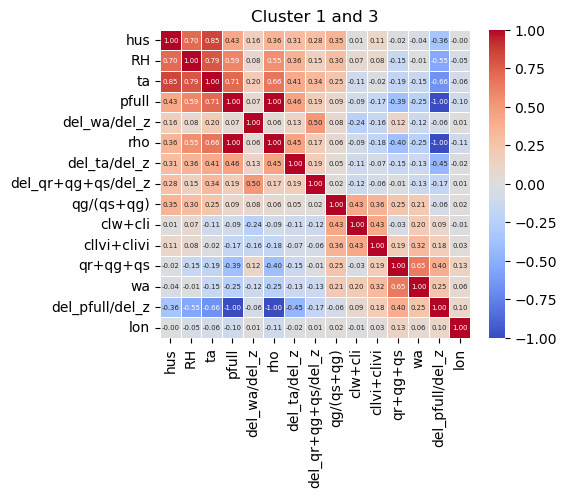

In [21]:
#Plot correlns of ft's in clusters 1 and 3
corr = df_features[np.append(c1_features, c3_features)].corr()

#plot correln. matrix
plt.figure(figsize=(5,4))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5,
            fmt=".2f",
            annot_kws={"size":5},
            vmin=-1, vmax=1)

plt.title('Cluster 1 and 3')

In [22]:
feature_names= [feature for feature in feature_names if feature not in ( 'hus', 'rho', 'qg/(qs+qg)')]

In [23]:
print(feature_names)

['lat', 'lon', 'RH', 'ta', 'wa', 'ua', 'va', 'pfull', 'clw+cli', 'qr+qg+qs', 'del_hus/del_z', 'del_ta/del_z', 'del_pfull/del_z', 'del_clw+cli/del_z', 'del_qr+qg+qs/del_z', 'del_wa/del_z', 'del_RH/del_z', 'cllvi+clivi']


In [24]:
output_fraction = 'qg/(qs+qg)'
X = df[feature_names] #X is a df 
y = df[output_fraction].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

#Train using xgb
#The following 'best' parameter values have been approximated from the values otained from the previous runs to find the best parameters in different datasets

# best_parameters= grid_search.best_params_
best_n_estimators=100 #best_parameters['n_estimators']
best_min_child_weight=30 #best_parameters['min_child_weight']
best_max_depth=10 #best_parameters['max_depth']
best_learning_rate=0.1 #best_parameters['learning_rate']

#XGBoost
# fit model
model = XGBRegressor(n_estimators=best_n_estimators, min_child_weight= best_min_child_weight, max_depth=best_max_depth, learning_rate=best_learning_rate, n_jobs=-1, random_state=0) #verbosity=3 (optional)

##Training
training_start_time = time.time()
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")


Training- Elapsed time: 0.6932 minutes


In [25]:
print("NaNs in y_train:", np.isnan(y_train).sum())
print("Infs in y_train:", np.isinf(y_train).sum())
print("Min/Max:", y_train.min(), y_train.max())

NaNs in y_train: 0
Infs in y_train: 0
Min/Max: 0.0 1.0


In [26]:
#Run this after running test code

# print("NaNs in y_test:", np.isnan(y_test).sum())
# print("Infs in y_test:", np.isinf(y_test).sum())
# print("Min/Max:", y_test.min(), y_test.max())

clw+cli: 27.0275 %
RH: 12.9077 %
ta: 11.1829 %
qr+qg+qs: 9.8448 %
del_clw+cli/del_z: 8.0692 %
del_RH/del_z: 6.1683 %
cllvi+clivi: 5.5184 %
del_wa/del_z: 4.7470 %
pfull: 2.2003 %
wa: 2.0308 %
del_qr+qg+qs/del_z: 1.8393 %
lat: 1.6069 %
del_pfull/del_z: 1.6039 %
del_ta/del_z: 1.2962 %
lon: 1.2424 %
ua: 1.1714 %
del_hus/del_z: 0.7954 %
va: 0.7476 %


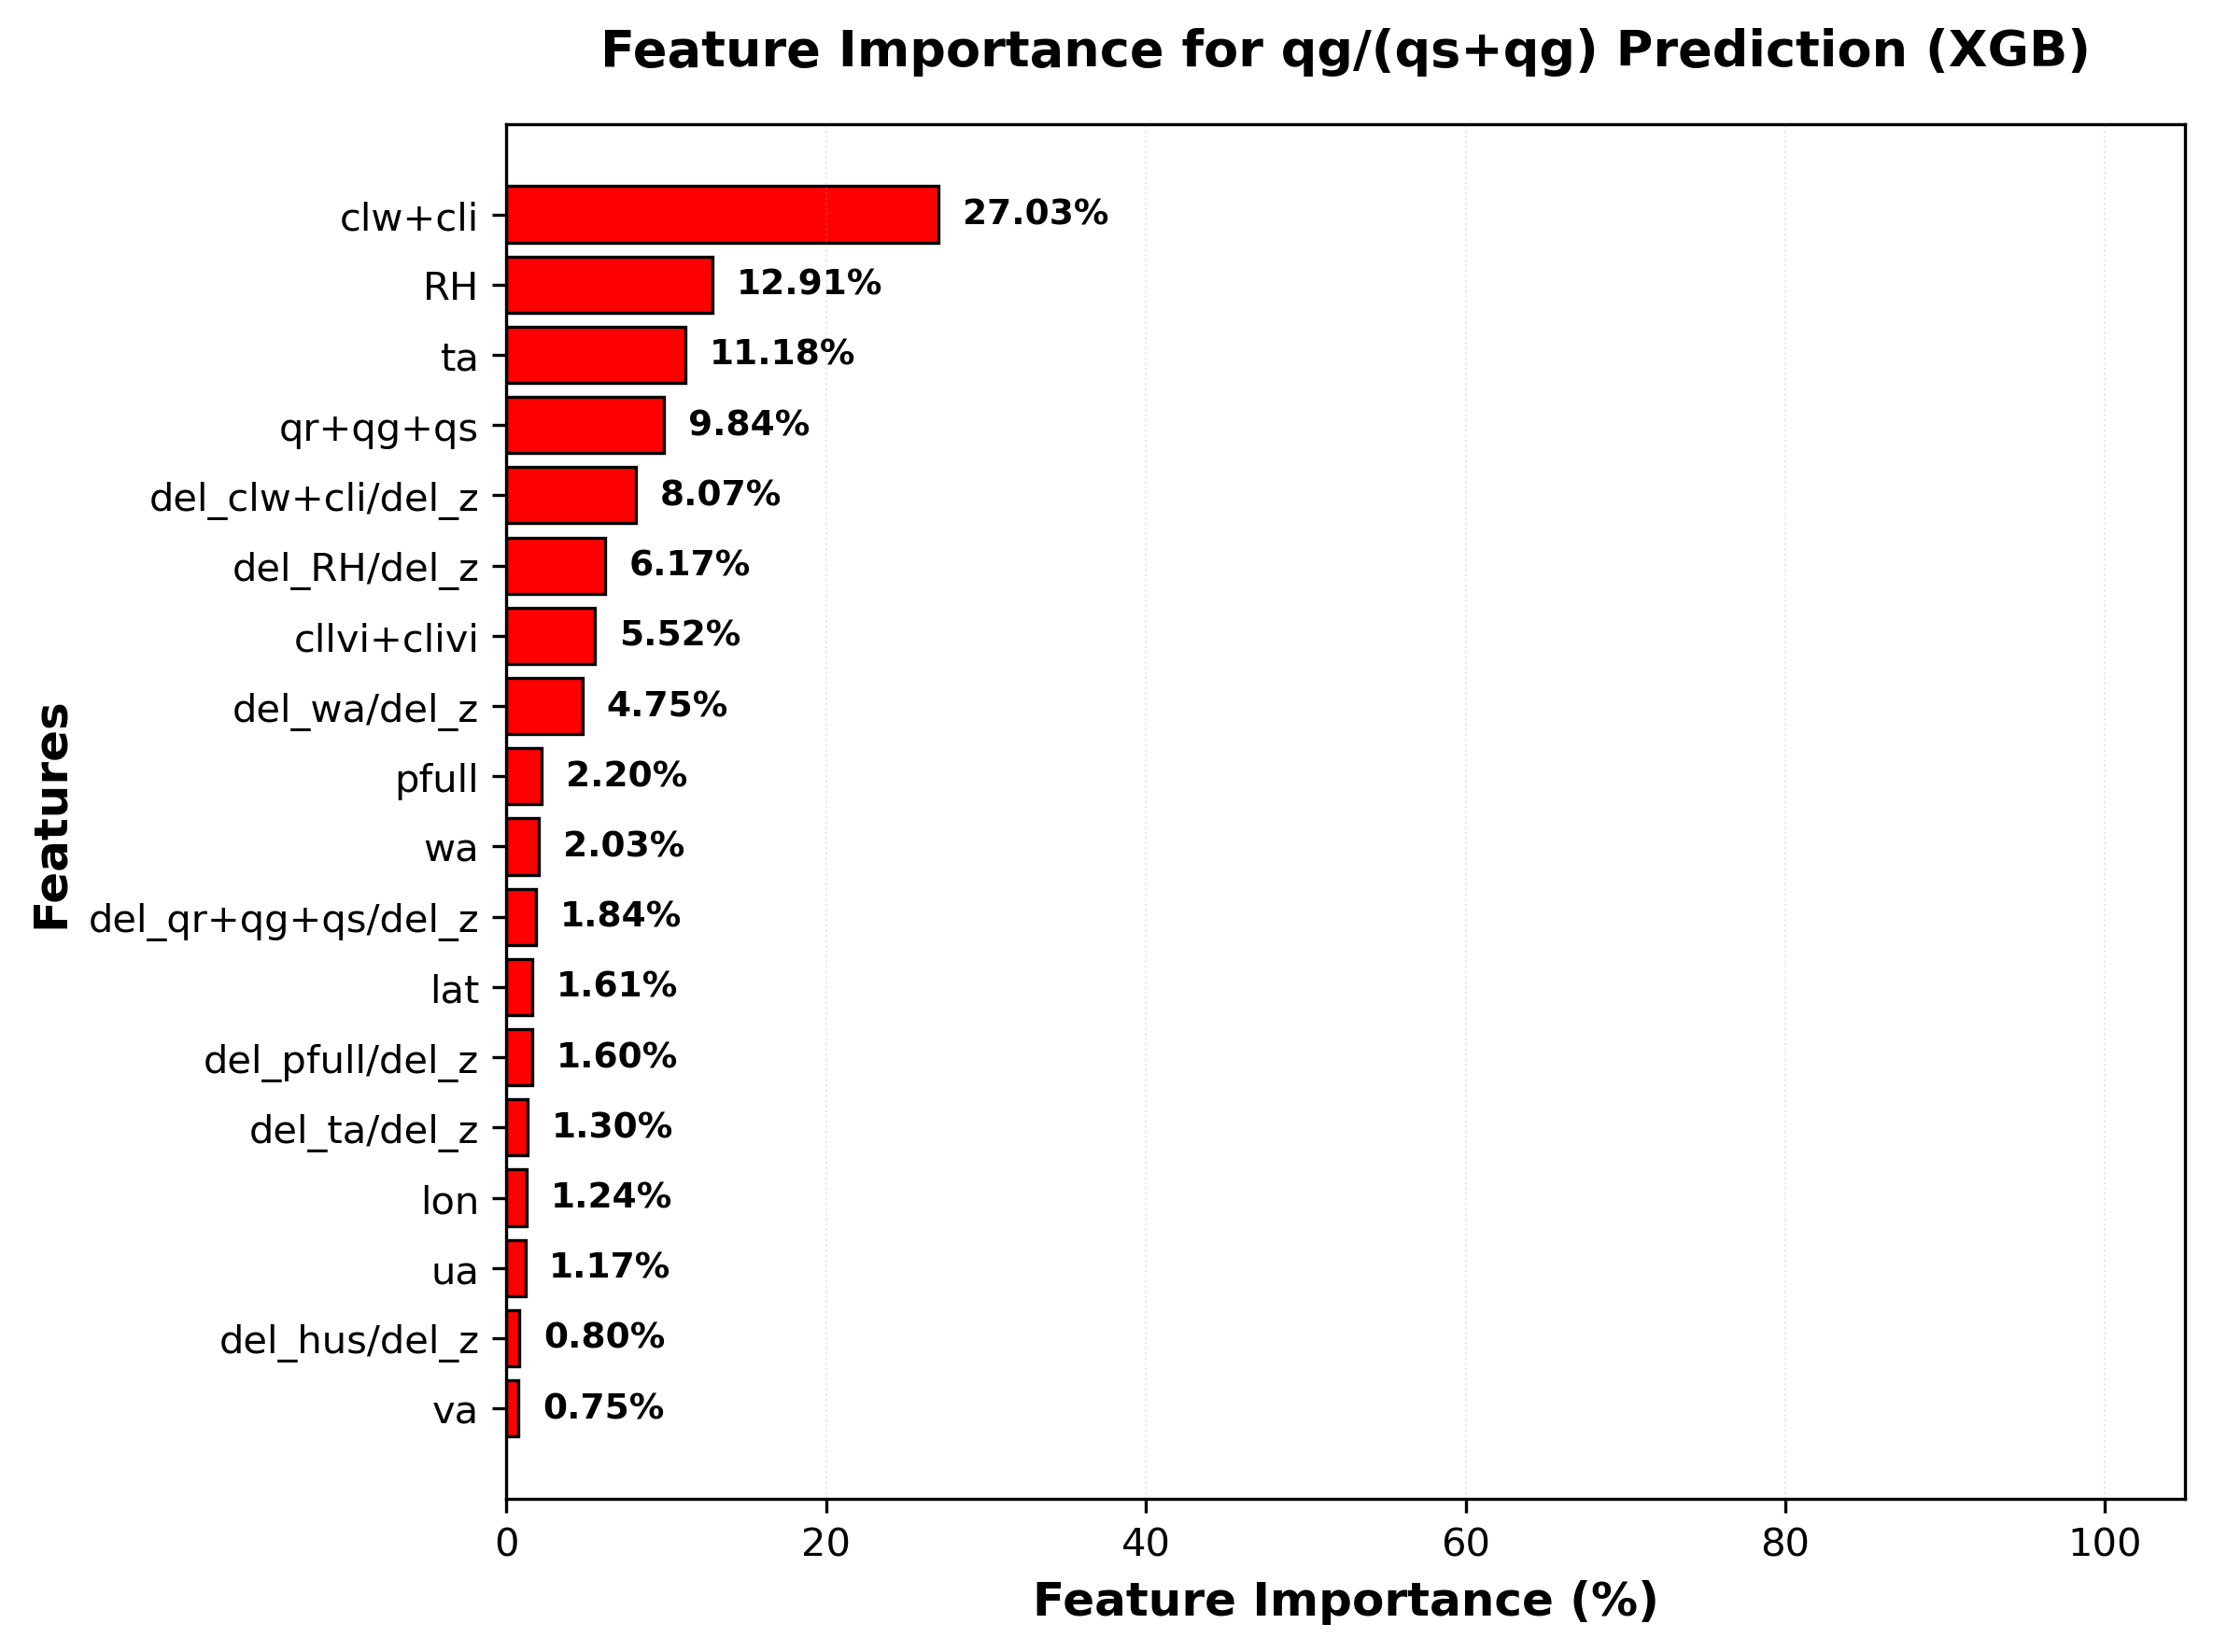

In [27]:
#Feature importance plot
importance = model.feature_importances_

#Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

#Convert to percentages
names = []
importances = []

for name, score in feature_scores:
    pct = score * 100
    names.append(name)
    importances.append(pct)
    print(f"{name}: {pct:.4f} %")

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

bars = ax.barh(names, importances, color='red', edgecolor='black', linewidth=0.8)


ax.set_xlabel("Feature Importance (%)", fontsize=12, fontweight='bold')
ax.set_ylabel("Features", fontsize=12, fontweight='bold')
#ax.set_title(r"XGBoost Feature Importance: Ice-Phase Hydrometeor Fraction $\mathbf{\left(\frac{q_g}{q_s + q_g}\right)}$", 
ax.set_title(f"Feature Importance for {output_fraction} Prediction (XGB)", 
            fontsize=13, fontweight='bold', pad=15)

ax.invert_yaxis() #Highest importance at the top

#Add percentage values on bars
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        width + 1.5,
        y,
        f"{width:.2f}%",
        va="center",
        fontsize=9,
        fontweight='bold'
    )
ax.set_xlim(0, 105)

ax.grid(True, axis='x', alpha=0.3, linestyle=':', linewidth=0.5, zorder=0)

plt.savefig(f"../output/{output_folder_name}/FeatureImportance_all_parameters.png",
    dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


Prediction- Elapsed time: 0.0016 minutes
max value of the fraction:  1.3489653
min value of the fraction:  -0.09868423
Out-of-range count =  35217
Out-of-range count percent =  2.7768447247283237  %
MSE_Test:  0.007495963
RMSE_TEST: 0.08657923340797424
mae_TEST: 0.04579603299498558
R² score:  0.894544243812561
Weighted R² score:  0.9513190798745232


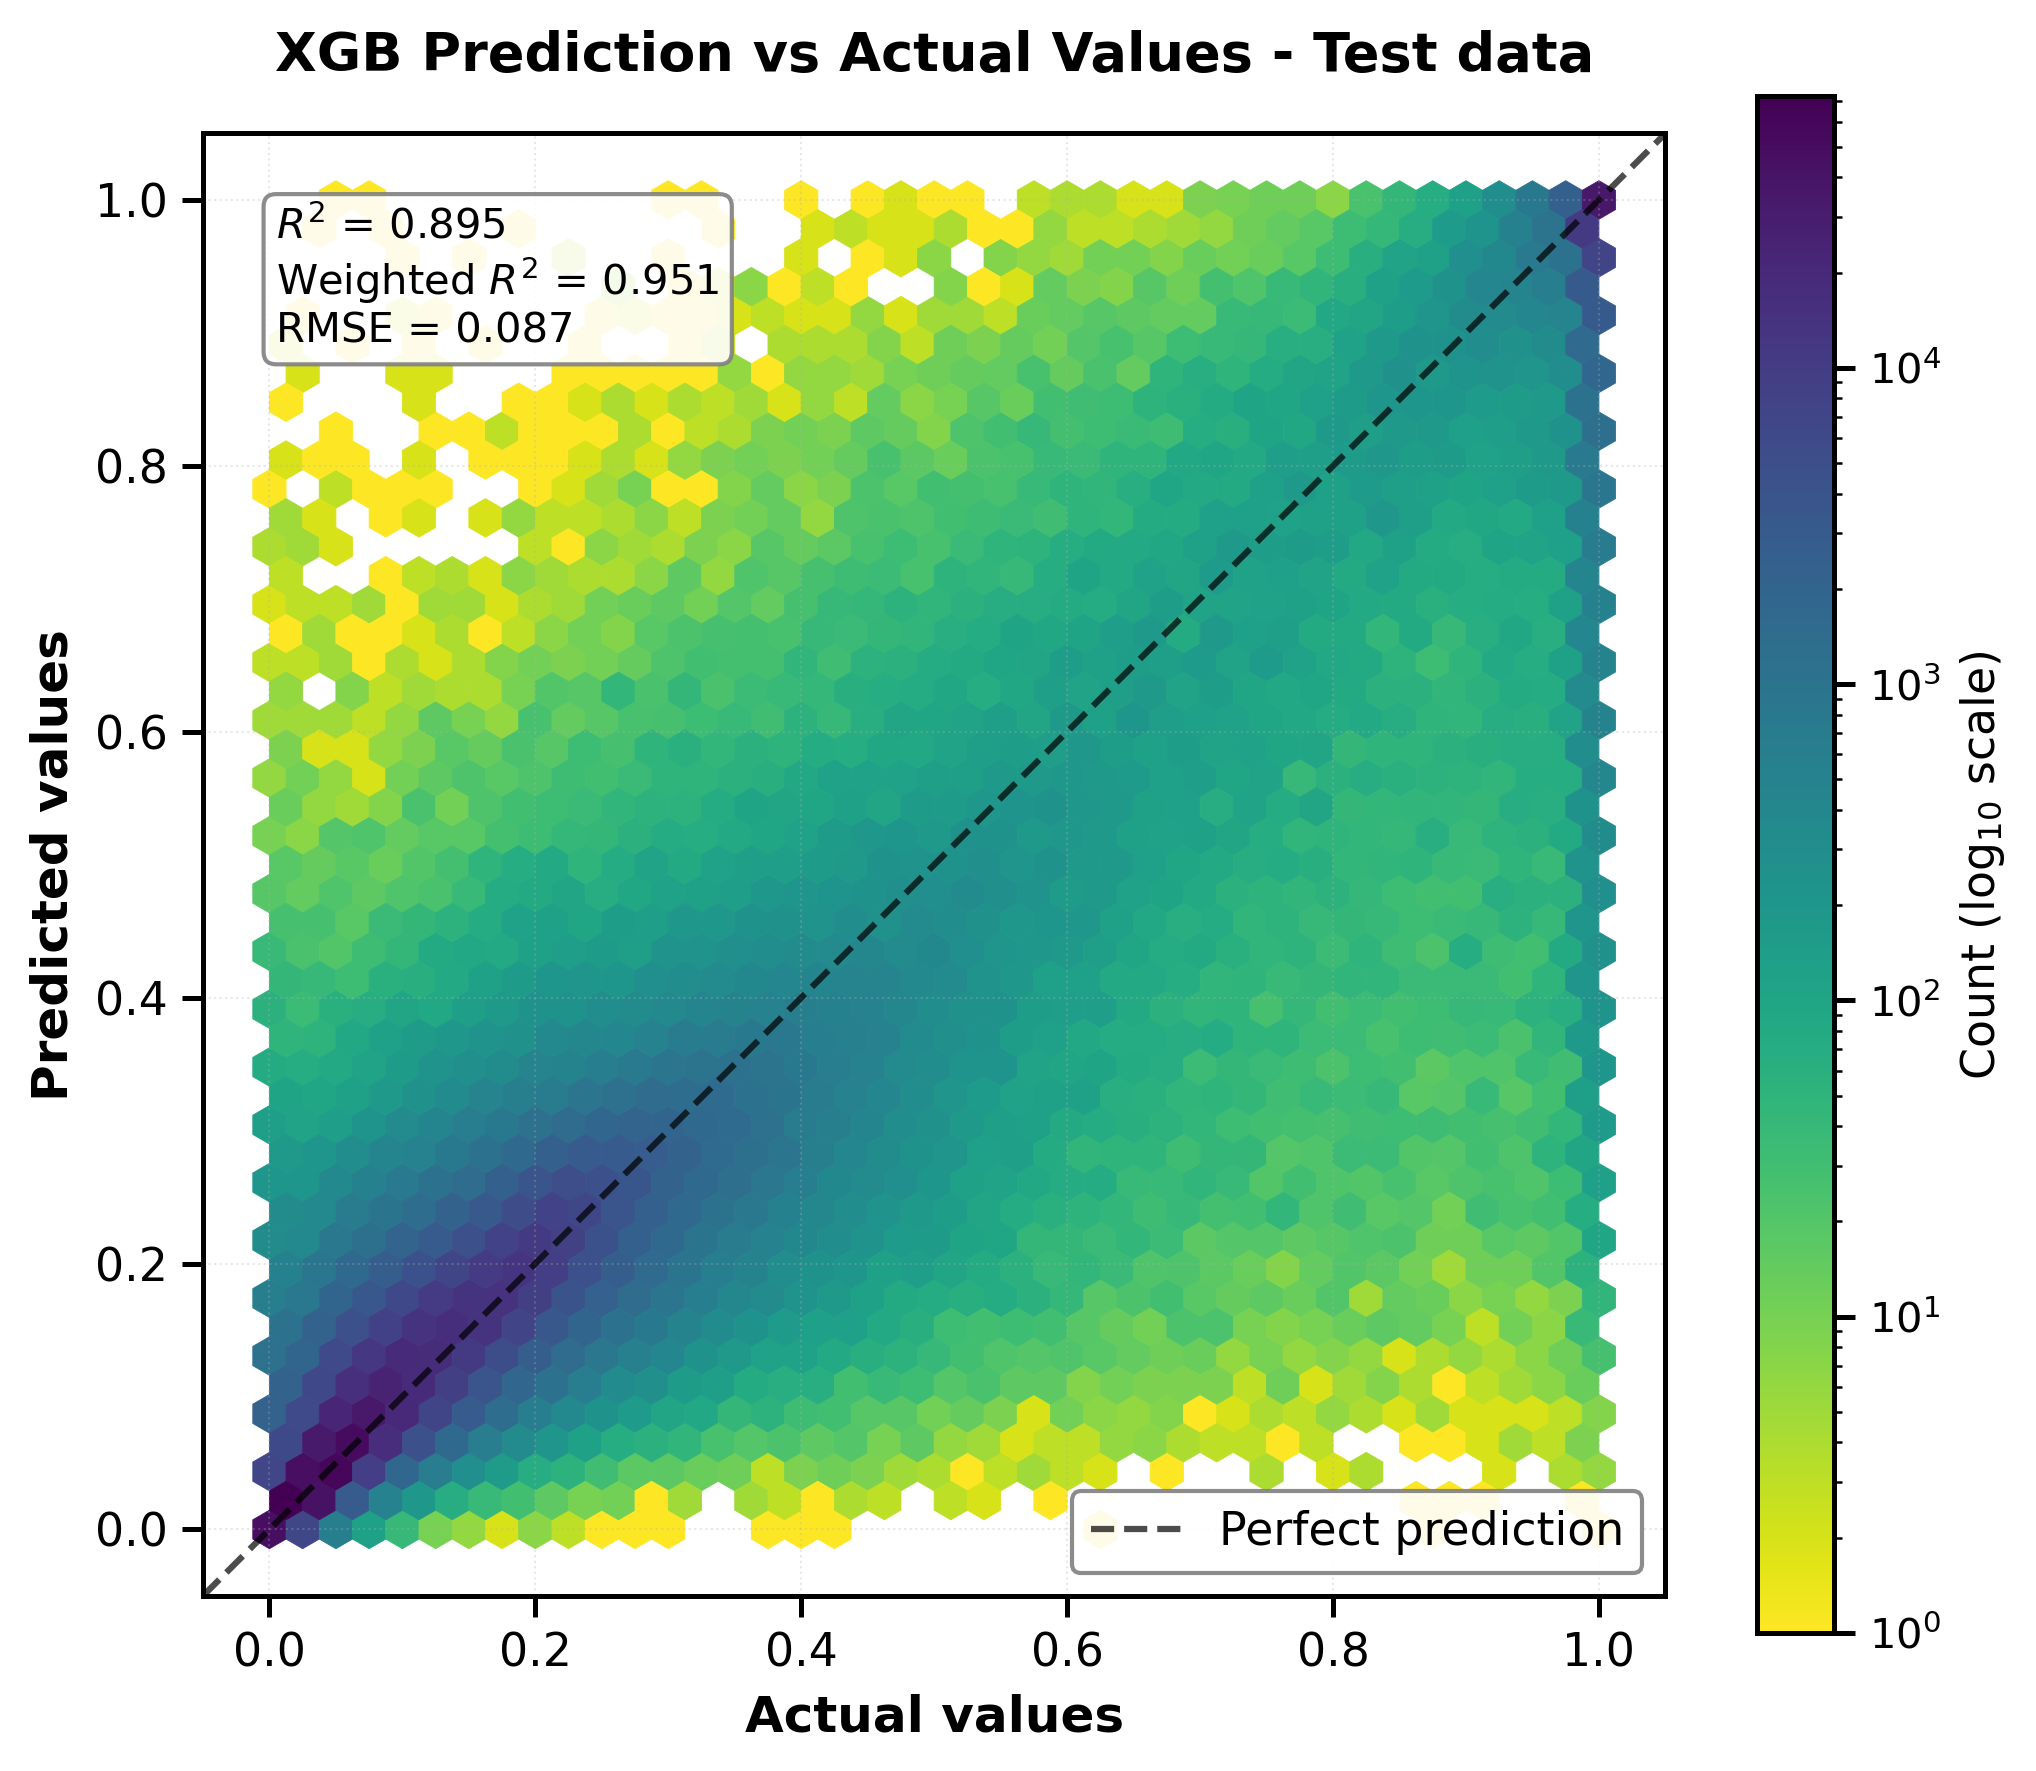

In [28]:
#Prediction

prediction_start_time = time.time()
y_pred = model.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

print("max value of the fraction: ", np.max(y_pred))
print("min value of the fraction: ", np.min(y_pred))

count=0
for i in y_pred:
    if i>1 or i<0:
        # print(i)
        count+=1
print("Out-of-range count = ", count)
print("Out-of-range count percent = ", 100*count/len(y_pred) , " %")

y_pred = np.clip(y_pred, 0, 1)
# y_test=y_test.ravel()
# y_pred=y_pred.ravel()

#Error Analysis on TEST data
#mse
mse= np.mean((y_test- y_pred)**2)
print('MSE_Test: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score: ", r2_sklearn)

#weighted_R2_test
df_test= df.loc[X_test.index]
weight = df_test['cell_area']*df_test['dzghalf']*df_test['rho']*( df_test['qs'] + df_test['qg'] ) 

weighted_r2 = weighted_r_squared(y_test, y_pred, weight)
print("Weighted R² score: ", weighted_r2)

#Plotting predicted vs actual values
from matplotlib.ticker import MaxNLocator

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

#Create hexbin plot with reversed colormap (light to dark)
#Using viridis_r for reversed viridis, or try 'YlOrRd' for yellow-orange-red
hb = ax.hexbin(
    # y_test.flatten(), 
    # y_test.values, 
    y_test, 
    y_pred.flatten(), 
    gridsize=40,
    cmap='viridis_r',  # Reversed: dark (low) to bright yellow (high)
    bins='log',
    mincnt=1,
    linewidths=0.2,
    edgecolors='face'
)

#Add colorbar with proper formatting
cbar = plt.colorbar(hb, ax=ax, label='Count (log$_{10}$ scale)')
cbar.ax.tick_params(labelsize=10)

#Calculate axis limits with padding
data_min = min(y_test.min(), y_pred.min())
data_max = max(y_test.max(), y_pred.max())
padding = (data_max - data_min) * 0.05
ax.set_xlim(data_min - padding, data_max + padding)
ax.set_ylim(data_min - padding, data_max + padding)

#Perfect prediction line
ax.plot(
    [data_min - padding, data_max + padding],
    [data_min - padding, data_max + padding],
    'k--',  # Black dashed line
    lw=1.5,
    alpha=0.7,
    label='Perfect prediction',
    zorder=3
)

#Add statistics text box
# textstr = f'$R^2$ = {r2_sklearn:.3f}\nModified $R^2$ = {modified_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
textstr = f'$R^2$ = {r2_sklearn:.3f}\nWeighted $R^2$ = {weighted_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray', linewidth=1)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)


ax.set_xlabel('Actual values', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted values', fontsize=12, fontweight='bold')
ax.set_title('XGB Prediction vs Actual Values - Test data', fontsize=13, fontweight='bold', pad=15)

#Make axes equal and square
ax.set_aspect('equal', adjustable='box')

ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5, zorder=0)
ax.legend(loc='lower right', framealpha=0.9, edgecolor='gray')

plt.tight_layout()

pred_vs_actual_output_path = os.path.join('../output', output_folder_name, pred_vs_actual_output_file_name1)
plt.savefig(pred_vs_actual_output_path,  bbox_inches='tight') 

plt.show()



In [29]:
#Train and predict using locals only

feature_names= [feature for feature in feature_names if feature not in ( 'hus', 'rho', 'qg/(qs+qg)', 'del_hus/del_z', 'del_ta/del_z', 'del_pfull/del_z', 'del_clw+cli/del_z', 'del_qr+qg+qs/del_z', 'del_wa/del_z', 'del_RH/del_z', 'cllvi+clivi' )]

output_fraction = 'qg/(qs+qg)'
X_locals = df[feature_names] #X is a df 
y_locals = df[output_fraction].values 

X_train, X_test, y_train, y_test = train_test_split(X_locals, y_locals, test_size=0.2, random_state=5)

#Train using xgb
#The following 'best' parameter values have been approximated from the values otained from the previous runs to find the best parameters in different datasets

# best_parameters= grid_search.best_params_
best_n_estimators=100 #best_parameters['n_estimators']
best_min_child_weight=30 #best_parameters['min_child_weight']
best_max_depth=10 #best_parameters['max_depth']
best_learning_rate=0.1 #best_parameters['learning_rate']

#XGBoost
# fit locals_model
locals_model = XGBRegressor(n_estimators=best_n_estimators, min_child_weight= best_min_child_weight, max_depth=best_max_depth, learning_rate=best_learning_rate, n_jobs=-1, random_state=0) #verbosity=3 (optional)

##Training
training_start_time = time.time()
locals_model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")


Training- Elapsed time: 0.5870 minutes


In [30]:
print("NaNs in y_train:", np.isnan(y_train).sum())
print("Infs in y_train:", np.isinf(y_train).sum())
print("Min/Max:", y_train.min(), y_train.max())

NaNs in y_train: 0
Infs in y_train: 0
Min/Max: 0.0 1.0


clw+cli: 36.0636 %
RH: 18.4686 %
qr+qg+qs: 14.4848 %
ta: 13.8742 %
pfull: 4.2283 %
wa: 4.1275 %
lat: 3.1469 %
lon: 2.5212 %
ua: 1.7174 %
va: 1.3676 %


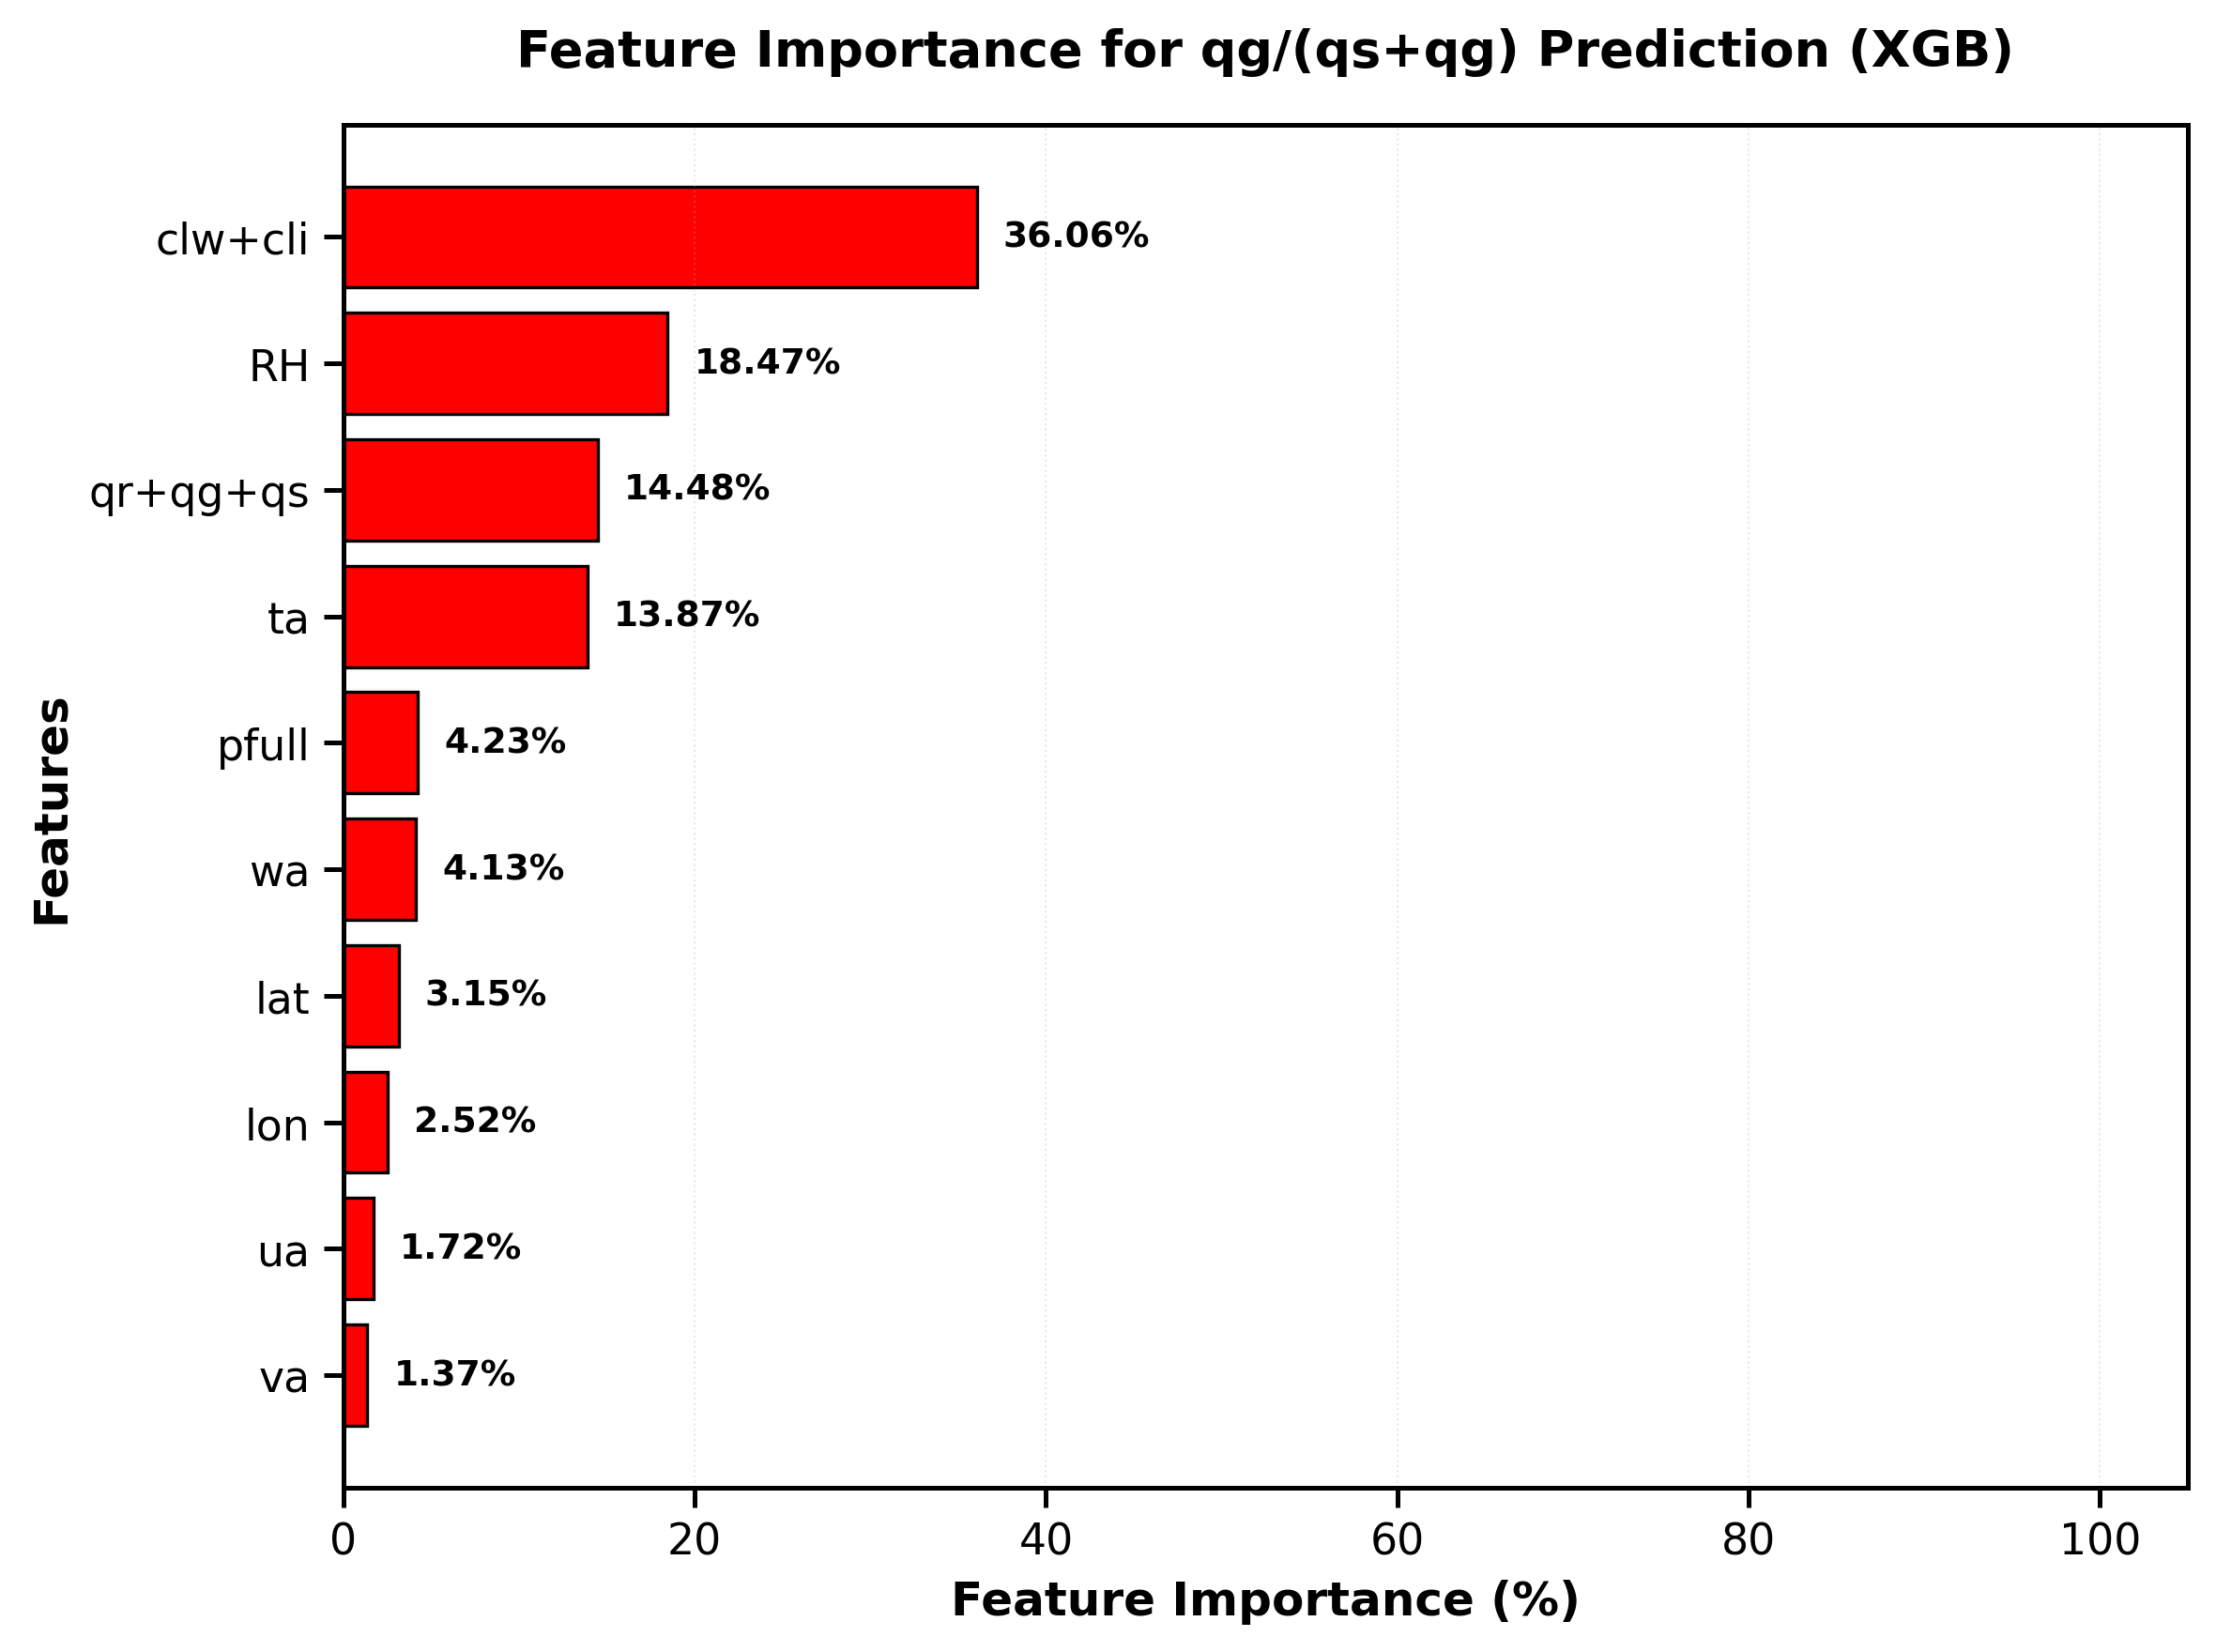

In [31]:
#Feature importance plot
importance = locals_model.feature_importances_

#Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

#Convert to percentages
names = []
importances = []

for name, score in feature_scores:
    pct = score * 100
    names.append(name)
    importances.append(pct)
    print(f"{name}: {pct:.4f} %")

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

bars = ax.barh(names, importances, color='red', edgecolor='black', linewidth=0.8)


ax.set_xlabel("Feature Importance (%)", fontsize=12, fontweight='bold')
ax.set_ylabel("Features", fontsize=12, fontweight='bold')
#ax.set_title(r"XGBoost Feature Importance: Ice-Phase Hydrometeor Fraction $\mathbf{\left(\frac{q_g}{q_s + q_g}\right)}$", 
ax.set_title(f"Feature Importance for {output_fraction} Prediction (XGB)", 
            fontsize=13, fontweight='bold', pad=15)

ax.invert_yaxis() #Highest importance at the top

#Add percentage values on bars
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        width + 1.5,
        y,
        f"{width:.2f}%",
        va="center",
        fontsize=9,
        fontweight='bold'
    )
ax.set_xlim(0, 105)

ax.grid(True, axis='x', alpha=0.3, linestyle=':', linewidth=0.5, zorder=0)

plt.savefig(f"../output/{output_folder_name}/FeatureImportance_locals_only.png",
    dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


Prediction- Elapsed time: 0.0013 minutes
max value of the fraction:  1.328307
min value of the fraction:  -0.105763055
Out-of-range count =  30253
Out-of-range count percent =  2.3854355412785297  %
MSE_Test:  0.01091496
RMSE_TEST_locals_only: 0.10447468608617783
mae_TEST: 0.05573727563023567
R² score:  0.8464446663856506


Weighted R² score:  0.9264105954652689


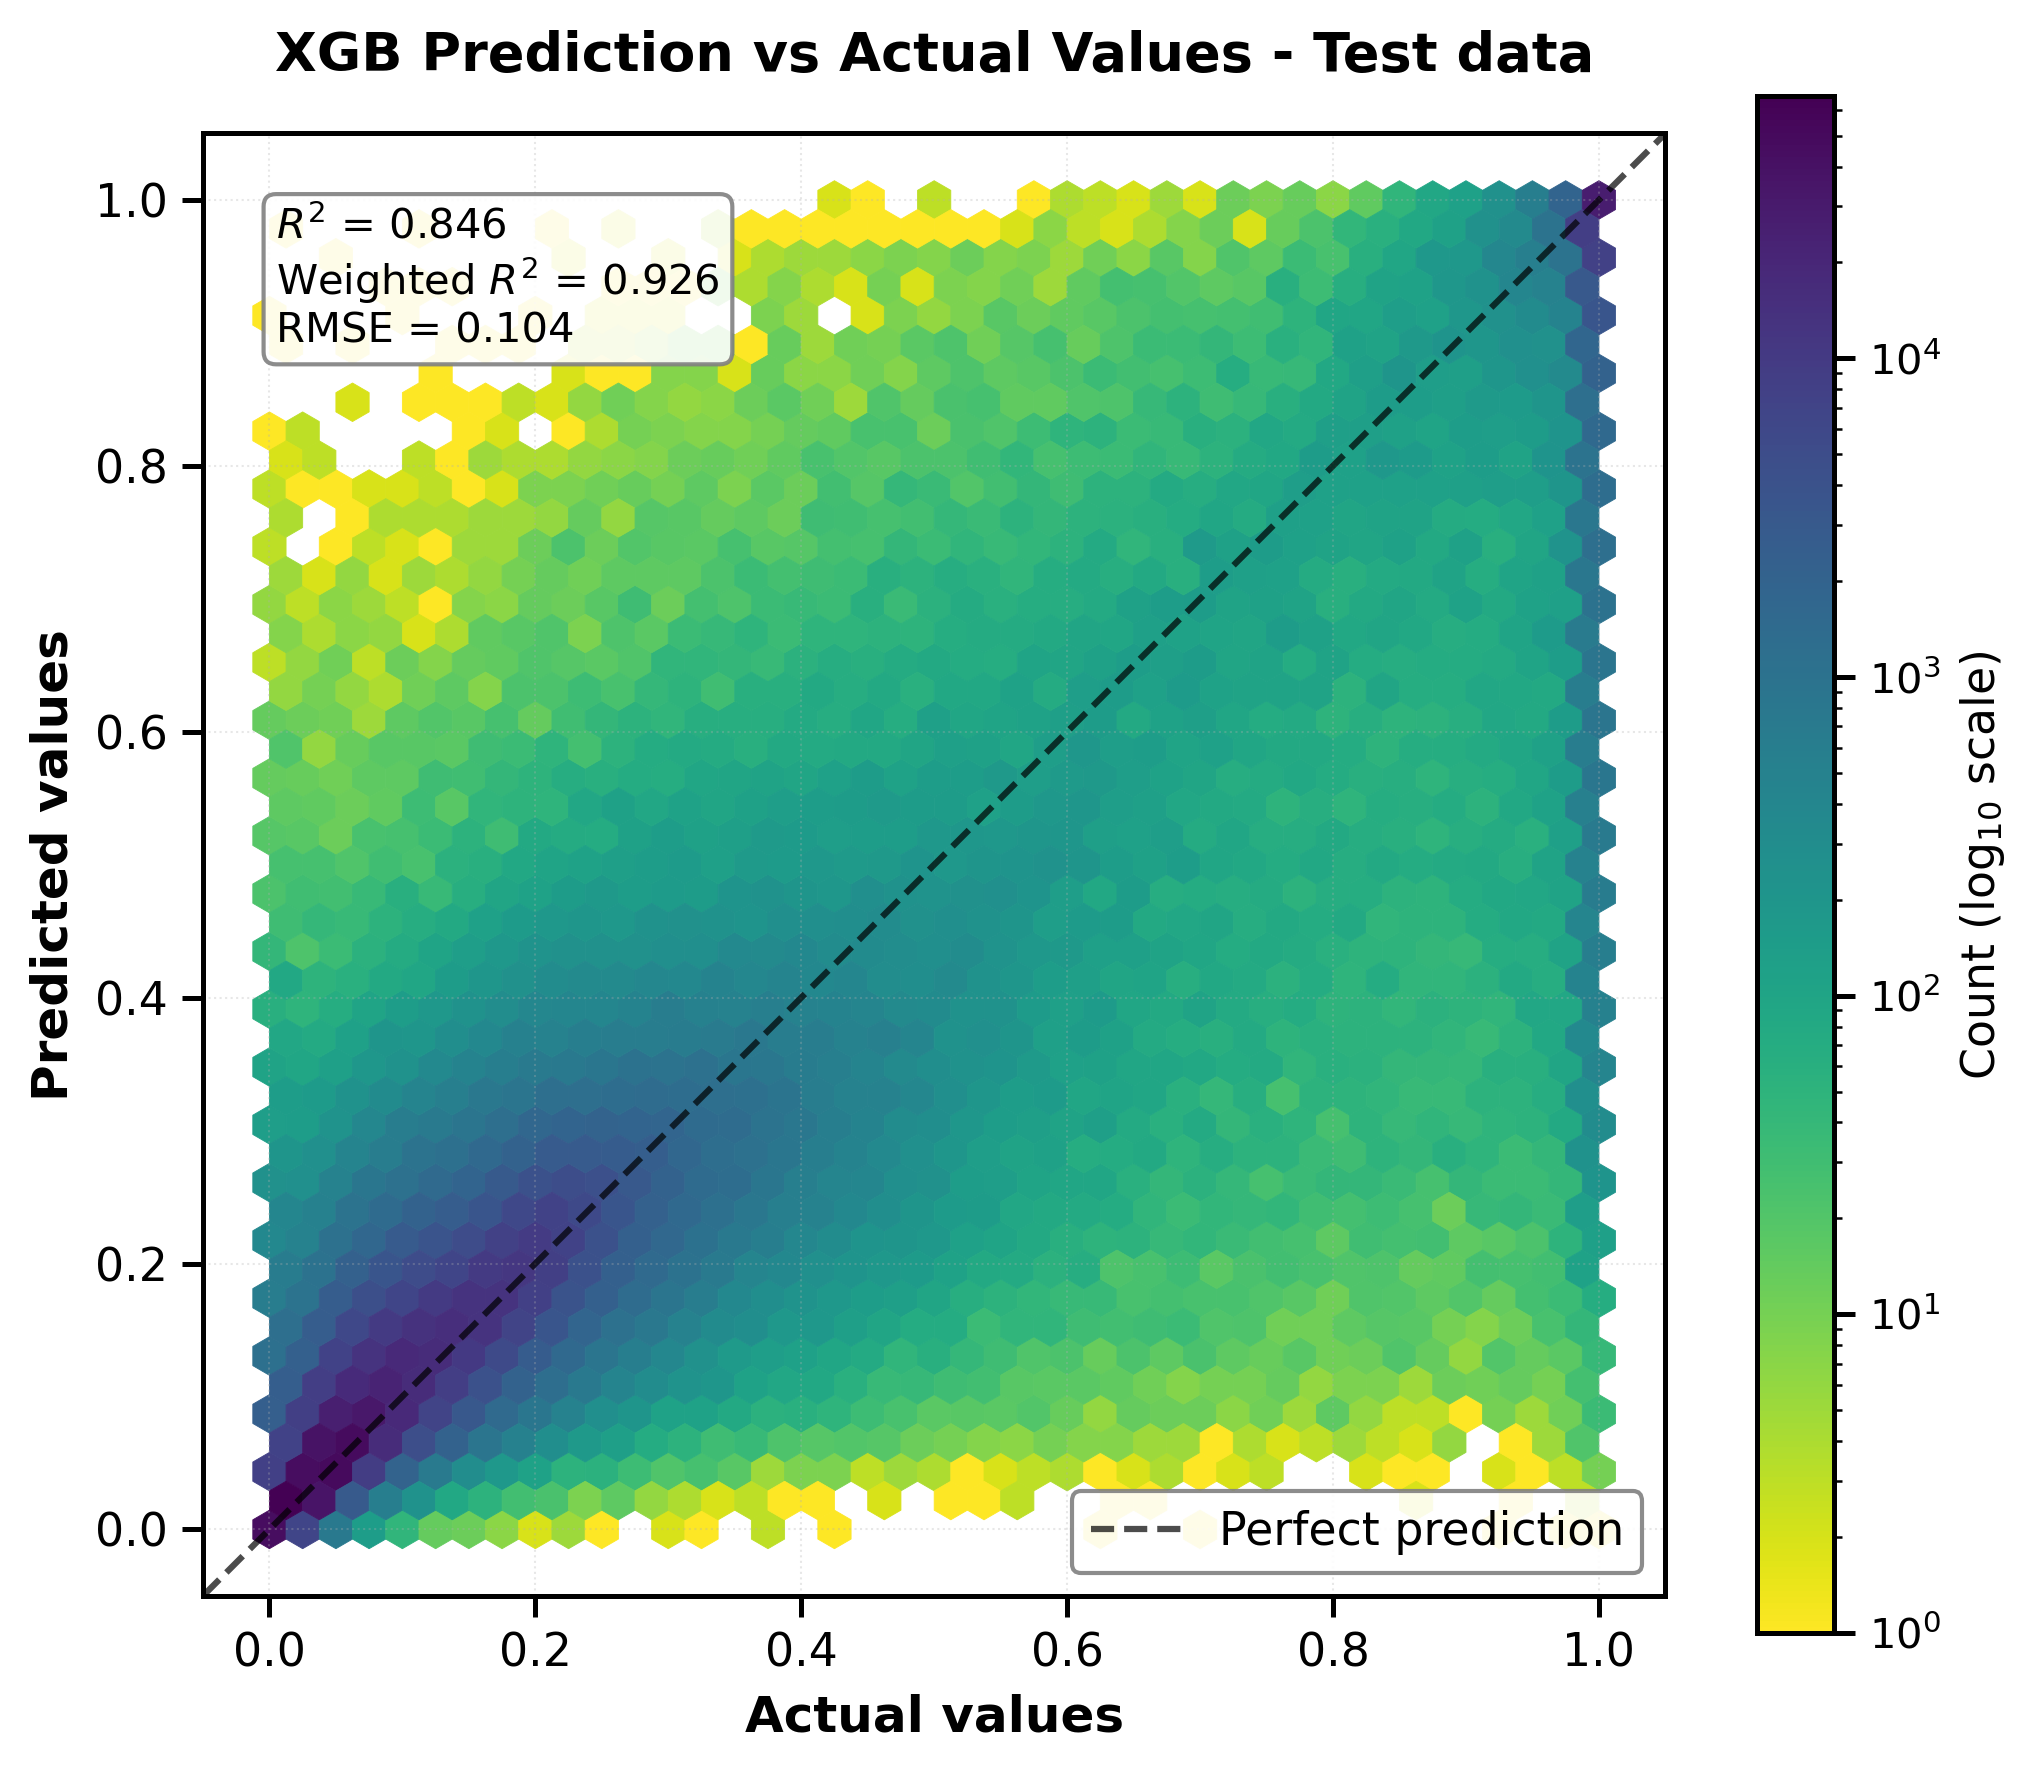

In [32]:
#Prediction

prediction_start_time = time.time()
y_pred = locals_model.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

print("max value of the fraction: ", np.max(y_pred))
print("min value of the fraction: ", np.min(y_pred))

count=0
for i in y_pred:
    if i>1 or i<0:
        # print(i)
        count+=1
print("Out-of-range count = ", count)
print("Out-of-range count percent = ", 100*count/len(y_pred) , " %")

y_pred = np.clip(y_pred, 0, 1)
# y_test=y_test.ravel()
# y_pred=y_pred.ravel()

#Error Analysis on TEST data
#mse
mse= np.mean((y_test- y_pred)**2)
print('MSE_Test: ', mse)

#rmse_test_locals_only
rmse_TEST_locals_only = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST_locals_only: {rmse_TEST_locals_only}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score: ", r2_sklearn)

#weighted_R2_test
df_test= df.loc[X_test.index]
weight = df_test['cell_area']*df_test['dzghalf']*df_test['rho']*( df_test['qs'] + df_test['qg'] ) 

weighted_r2 = weighted_r_squared(y_test, y_pred, weight)
print("Weighted R² score: ", weighted_r2)

#Plotting predicted vs actual values
from matplotlib.ticker import MaxNLocator

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

#Create hexbin plot with reversed colormap (light to dark)
#Using viridis_r for reversed viridis, or try 'YlOrRd' for yellow-orange-red
hb = ax.hexbin(
    # y_test.flatten(), 
    # y_test.values, 
    y_test, 
    y_pred.flatten(), 
    gridsize=40,
    cmap='viridis_r',  # Reversed: dark (low) to bright yellow (high)
    bins='log',
    mincnt=1,
    linewidths=0.2,
    edgecolors='face'
)

#Add colorbar with proper formatting
cbar = plt.colorbar(hb, ax=ax, label='Count (log$_{10}$ scale)')
cbar.ax.tick_params(labelsize=10)

#Calculate axis limits with padding
data_min = min(y_test.min(), y_pred.min())
data_max = max(y_test.max(), y_pred.max())
padding = (data_max - data_min) * 0.05
ax.set_xlim(data_min - padding, data_max + padding)
ax.set_ylim(data_min - padding, data_max + padding)

#Perfect prediction line
ax.plot(
    [data_min - padding, data_max + padding],
    [data_min - padding, data_max + padding],
    'k--',  # Black dashed line
    lw=1.5,
    alpha=0.7,
    label='Perfect prediction',
    zorder=3
)

#Add statistics text box
# textstr = f'$R^2$ = {r2_sklearn:.3f}\nModified $R^2$ = {modified_r2:.3f}\nRMSE = {rmse_TEST_locals_only:.3f}'
textstr = f'$R^2$ = {r2_sklearn:.3f}\nWeighted $R^2$ = {weighted_r2:.3f}\nRMSE = {rmse_TEST_locals_only:.3f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray', linewidth=1)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)


ax.set_xlabel('Actual values', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted values', fontsize=12, fontweight='bold')
ax.set_title('XGB Prediction vs Actual Values - Test data', fontsize=13, fontweight='bold', pad=15)

#Make axes equal and square
ax.set_aspect('equal', adjustable='box')

ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5, zorder=0)
ax.legend(loc='lower right', framealpha=0.9, edgecolor='gray')

plt.tight_layout()

pred_vs_actual_output_path = os.path.join('../output', output_folder_name, pred_vs_actual_output_file_name2)
plt.savefig(pred_vs_actual_output_path,  bbox_inches='tight') 

plt.show()



In [33]:
# from mlxtend.evaluate import paired_ttest_kfold_cv

# t, p = paired_ttest_kfold_cv(estimator1=model,
#                               estimator2=locals_model,
#                               X=X.values, y=y, cv=5, scoring='neg_mean_squared_error',
#                               random_seed=1)

# print('t statistic: %.3f' % t)
# print('p value: %.3f' % p)

# if p <= 0.05:
#     print('Difference between the model trained on both local and non-local parameters and that trained on local parameters only is statistically significant')
# else:
#     print('Difference between the model trained on both local and non-local parameters and that trained on local parameters only is not statistically significant')

# #Collect t and p-values for each pair of algorithms and store them in lists and ultimately store them all in a csv file

# results = []

# significant = "Yes" if p < 0.05 else "No"
# results.append(["All parameters and Only Local Parameters", t, p, significant])

# #write to csv file

# with open(f"../output/{output_folder_name}/k-fold-cv_and_paired-t-test_results.csv", "w", newline="") as f:
#     writer = csv.writer(f)
#     writer.writerow(["Comparison", "t-statistic", "p-value", "Significant?"])
#     writer.writerows(results)



In [ ]:


#Comparing model and locals_model using parallel processing

from sklearn.model_selection import KFold, cross_val_score
from scipy import stats

kf = KFold(n_splits=5, shuffle=True, random_state=1)

y = df[output_fraction].values
scores1 = cross_val_score(model, X, y,
                          cv=kf,
                          scoring='neg_mean_squared_error',
                          n_jobs=-1)

scores2 = cross_val_score(locals_model, X_locals, y_locals,
                          cv=kf,
                          scoring='neg_mean_squared_error',
                          n_jobs=-1)


diff = scores1 - scores2
t, p = stats.ttest_1samp(diff, popmean=0)

print('t statistic: %.3f' % t)
print('p value: %.3f' % p)

if p <= 0.05:
    print('Difference between model and locals_model is statistically significant')
else:
    print('Difference between model and locals_model is not statistically significant')

results=[]
significant = "Yes" if p < 0.05 else "No"
results.append(["model and locals_model", t, p, significant])

#write to csv file

with open(f"../output/{output_folder_name}/k-fold-cv_and_paired-t-test_results.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Comparison", "t-statistic", "p-value", "Significant?"])
    writer.writerows(results)

t statistic: 115.844
p value: 0.000
Difference between model and locals_model is statistically significant
